# Network Expansion
## Model 2 (Test) - Intertemporal Deterministic Model

True multi-year formulation solved in one MILP. Investments are time-indexed (years), activations are non-decreasing, and capacity reinforcements accumulate. Costs are discounted and budgets enforced per year.

### 1 - Imports

In [1]:
import numpy as np
import pandas as pd

from src.classes import DistributionNetwork, Substation
from src.solver import solve_network_intertemporal

### 2 - Define the Distribution Network (shared across years)

In [2]:
# Nodes and loads
NODES = [f"N{i}" for i in range(1, 14)]
LOADS = [f"D{i}" for i in range(1, 11)]

# Initial substation
S1 = Substation("S1", "N4", 40, ['N3', 'N5', 'N9'], r_cost=200, edge_cost=50)
SUBSTATIONS = [S1]

line_cost = 50

base_load_capacity = {
    'D1': 6, 'D2': 3, 'D3': 2, 'D4': 5, 'D5': 3,
    'D6': 2, 'D7': 3, 'D8': 5, 'D9': 4, 'D10': 6
}

loads_locations = {
    'D1': 'N1', 'D2': 'N2', 'D3': 'N3', 'D4': 'N6', 'D5': 'N7',
    'D6': 'N8', 'D7': 'N9', 'D8': 'N11', 'D9': 'N12', 'D10': 'N13'
}

nodes_connected = {
    'N1': ['N2'],
    'N2': ['N1', 'N3'],
    'N3': ['N2', 'N4'],
    'N4': ['N3', 'N5', 'N9'],
    'N5': ['N4', 'N6'],
    'N6': ['N5','N7', 'N8'],
    'N7': ['N6'],
    'N8': ['N6'],
    'N9': ['N4', 'N10'],
    'N10': ['N9', 'N11', 'N13'],
    'N11': ['N10', 'N12'],
    'N12': ['N11'],
    'N13': ['N10']
}

DistributionNetwork = DistributionNetwork(
    NODES.copy(),
    LOADS.copy(),
    SUBSTATIONS.copy(),
    base_load_capacity.copy(),
    nodes_connected.copy(),
    loads_locations.copy(),
    line_cost
)

# Candidate substations (same as Model 1)
capacity = 15
s_cost = 100       # activation cost
l_cost = line_cost # feeder line cost
r_cost = 200       # capacity reinforcement cost

S2 = Substation("S2", "N14", capacity, ['N2'], r_cost, edge_cost=l_cost, fix_cost=s_cost)
S3 = Substation("S3", "N15", capacity, ['N6'], r_cost, edge_cost=l_cost, fix_cost=s_cost)
S4 = Substation("S4", "N16", capacity, ['N11', 'N13'], r_cost, edge_cost=l_cost, fix_cost=s_cost)

DistributionNetwork.add_candidate_substations([S2, S3, S4])

### 3 - Multi-year data and scenario (deterministic growth)

In [3]:
years = list(range(1, 11))
# Annual demand growth 
demand_rate = 0.089
R = 10                             # Size of capacity reinforcement
# Dynamic annual budgets: starts at 550 and grows by 25 per year
B = {t: 550 + 25*(t-1) for t in years}
dr = 0.05                          # Discount rate

# Build per-year demand dictionaries
demands = {}
for t in years:
    factor = (1 + demand_rate) ** (t - 1)
    demands[t] = {ld: val * factor for ld, val in base_load_capacity.items()}

# Quick check of total demand per year
system_demand = {t: round(sum(demands[t].values()), 2) for t in years}
system_demand

# Connection change penalties
connect_cost = 25
disconnect_cost = 0

### 4 - Solve intertemporal model

In [4]:
solution = solve_network_intertemporal(
    DistributionNetwork,
    R=R,
    B=B,
    dr=dr,
    years=years,
    demands=demands,
    op_cost=2,
    connect_cost=connect_cost,
    disconnect_cost=disconnect_cost,
    OutputFlag=0
)

Set parameter Username
Set parameter LicenseID to value 2706891
Academic license - for non-commercial use only - expires 2026-09-10


### 5 - Summaries

In [5]:
S_idx = list(range(1, len(DistributionNetwork.SUBSTATIONS)+1))
base_edge_cost = DistributionNetwork.edge_cost

lines_added = {}
for t in years:
    added = set()
    for (i, j, s, tau), val in solution['b_on'].items():
        if tau == t and val > 0.5:
            e = (i, j)
            if base_edge_cost.get(e, 0) > 0:
                added.add(e)
    lines_added[t] = sorted(list(added))

summary = pd.DataFrame({
    'Budget': [B[t] if not isinstance(B, dict) else B[t] for t in years],
    'System Demand': [system_demand[t] for t in years],
    'System Supply': [round(sum(solution['r'][(s, t)] for s in S_idx), 2) for t in years],
    'System Capacity': [sum(solution['P'][(s, t)] for s in S_idx) for t in years],
    'Substations Active': [[s for s in S_idx if solution['w'][(s, t)] > 0.5] for t in years],
    'Lines Added': [lines_added[t] for t in years],
    'Cost substation (nom)': [round(solution['cost_components_nominal'][t]['substation'], 2) for t in years],
    'Cost lines (nom)': [round(solution['cost_components_nominal'][t]['lines'], 2) for t in years],
    'Cost connect (nom)': [round(solution['cost_components_nominal'][t]['connect'], 2) for t in years],
    'Cost disconnect (nom)': [round(solution['cost_components_nominal'][t]['disconnect'], 2) for t in years],
    'Cost reinforcement (nom)': [round(solution['cost_components_nominal'][t]['reinforcement'], 2) for t in years],
    'Cost opex (nom)': [round(solution['cost_components_nominal'][t]['opex'], 2) for t in years],
    'Cost (nominal)': [round(solution['cost_per_year_nominal'][t], 2) for t in years],
    'Cost (discounted)': [round(solution['cost_per_year'][t], 2) for t in years],
}, index=years)

summary_totals = pd.DataFrame({
    'Budget': [''],
    'System Demand': [''],
    'System Supply': [''],
    'System Capacity': [''],
    'Substations Active': [''],
    'Lines Added': [''],
    'Cost substation (nom)': [round(sum(solution['cost_components_nominal'][t]['substation'] for t in years), 2)],
    'Cost lines (nom)': [round(sum(solution['cost_components_nominal'][t]['lines'] for t in years), 2)],
    'Cost connect (nom)': [round(sum(solution['cost_components_nominal'][t]['connect'] for t in years), 2)],
    'Cost disconnect (nom)': [round(sum(solution['cost_components_nominal'][t]['disconnect'] for t in years), 2)],
    'Cost reinforcement (nom)': [round(sum(solution['cost_components_nominal'][t]['reinforcement'] for t in years), 2)],
    'Cost opex (nom)': [round(sum(solution['cost_components_nominal'][t]['opex'] for t in years), 2)],
    'Cost (nominal)': [round(sum(solution['cost_per_year_nominal'][t] for t in years), 2)],
    'Cost (discounted)': [round(sum(solution['cost_per_year'][t] for t in years), 2)],
}, index=['Total'])

summary = pd.concat([summary, summary_totals])
summary


,Budget,System Demand,System Supply,System Capacity,Substations Active,Lines Added,Cost substation (nom),Cost lines (nom),Cost connect (nom),Cost disconnect (nom),Cost reinforcement (nom),Cost opex (nom),Cost (nominal),Cost (discounted)
1,550,39.0,39.0,55.0,"[1, 2]","[(2, 14)]",100.0,50.0,0.0,0.0,0.0,4.0,154.0,154.00
2,575,42.47,42.47,55.0,"[1, 2]",[],0.0,0.0,0.0,0.0,0.0,4.0,4.0,3.81
3,600,46.25,46.25,55.0,"[1, 2]",[],0.0,0.0,0.0,0.0,0.0,4.0,4.0,3.63
4,625,50.37,50.37,55.0,"[1, 2]",[],0.0,0.0,0.0,0.0,0.0,4.0,4.0,3.46
5,650,54.85,54.85,65.0,"[1, 2]",[],0.0,0.0,0.0,0.0,200.0,4.0,204.0,167.83
6,675,59.73,59.73,80.0,"[1, 2, 4]","[(13, 16)]",100.0,50.0,25.0,0.0,0.0,6.0,181.0,141.82
7,700,65.05,65.05,80.0,"[1, 2, 4]",[],0.0,0.0,0.0,0.0,0.0,6.0,6.0,4.48
8,725,70.84,70.84,80.0,"[1, 2, 4]",[],0.0,0.0,0.0,0.0,0.0,6.0,6.0,4.26
9,750,77.14,77.14,90.0,"[1, 2, 4]",[],0.0,0.0,0.0,0.0,200.0,6.0,206.0,139.43
10,775,84.01,84.01,90.0,"[1, 2, 4]",[],0.0,0.0,0.0,0.0,0.0,6.0,6.0,3.87


### 6 - Final year assignments

In [6]:
S_idx = list(np.arange(1, len(DistributionNetwork.SUBSTATIONS)+1))
N_idx = list(np.arange(1, len(DistributionNetwork.NODES)+1))

# table of rows = nodes, columns = years, values = assigned substation id
assignments = {y: [] for y in years}
for y in years:
    for n in N_idx:
        sub_assigned = ''
        for s in S_idx:
            if solution['y'][(n, s, y)] > 0.5:
                sub_assigned = DistributionNetwork.SUBSTATIONS[s-1].id
                break
        assignments[y].append(sub_assigned)

assignments_df = pd.DataFrame(assignments, index=[DistributionNetwork.NODES[n-1] for n in N_idx])
assignments_df.index.name = 'Node'
assignments_df

,1,2,3,4,5,6,7,8,9,10
Node,,,,,,,,,,
N1,S2,S2,S2,S2,S2,S2,S2,S2,S2,S2
N2,S2,S2,S2,S2,S2,S2,S2,S2,S2,S2
N3,S2,S2,S2,S2,S2,S2,S2,S2,S2,S2
N4,S1,S1,S1,S1,S1,S1,S1,S1,S1,S1
N5,S1,S1,S1,S1,S1,S1,S1,S1,S1,S1
N6,S1,S1,S1,S1,S1,S1,S1,S1,S1,S1
N7,S1,S1,S1,S1,S1,S1,S1,S1,S1,S1
N8,S1,S1,S1,S1,S1,S1,S1,S1,S1,S1
N9,S1,S1,S1,S1,S1,S1,S1,S1,S1,S1


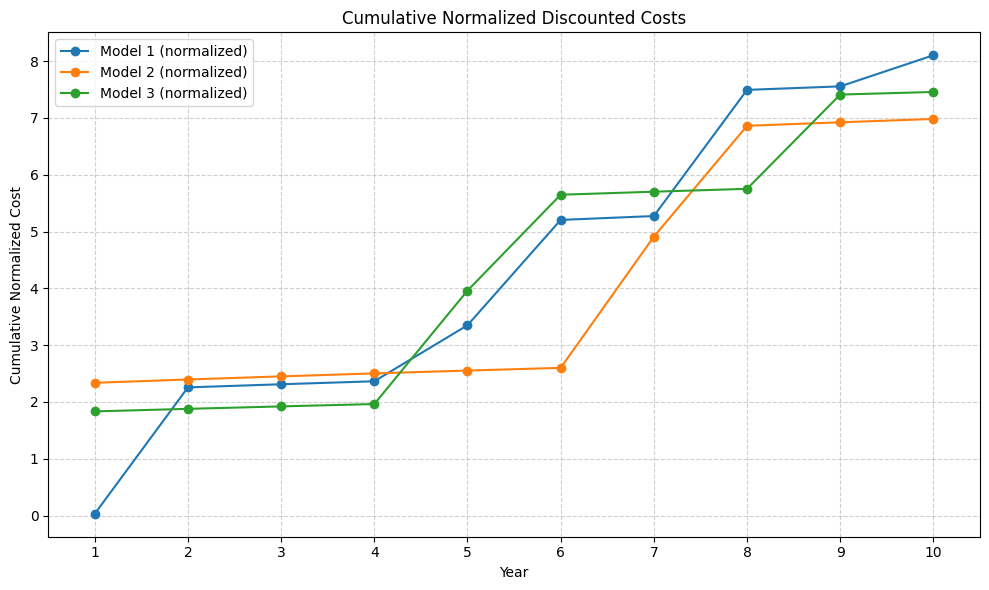

In [7]:
import matplotlib.pyplot as plt

col1 = np.array([2.00, 146.67, 3.63, 3.46, 64.99, 122.23, 4.48, 146.40, 4.06, 36.10])
col2 = np.array([154.00, 3.81, 3.63, 3.46, 3.29, 3.13, 152.23, 128.63, 4.06, 3.87])
col3 = np.array([154.00, 3.81, 3.63, 3.46, 167.83, 141.82, 4.48, 4.26, 139.43, 3.87])

# Corresponding demands:
demand1 = 65.89
demand2 = 65.89
demand3 = 84.01

norm1 = col1 / demand1
norm2 = col2 / demand2
norm3 = col3 / demand3

cum1 = np.cumsum(norm1)
cum2 = np.cumsum(norm2)
cum3 = np.cumsum(norm3)

# Use the notebook 'years' variable (1..10)
x = years  # years is defined earlier in the notebook

plt.figure(figsize=(10,6))

plt.plot(x, cum1, marker='o', label='Model 1 (normalized)')
plt.plot(x, cum2, marker='o', label='Model 2 (normalized)')
plt.plot(x, cum3, marker='o', label='Model 3 (normalized)')

plt.xlabel("Year")
plt.ylabel("Cumulative Normalized Cost")
plt.title("Cumulative Normalized Discounted Costs")
plt.xticks(x)           

plt.xlim(min(x) - 0.5, max(x) + 0.5)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
